# P2 Diagnostics: Unit Resolution And Error Decomposition

This notebook diagnoses the failed R2 gate without retraining the formal model.
The HDF5 stores no unit metadata. PiNN documentation and model code identify
dipole properties as atomic units, and Batt-SLM `params.yml` uses `d_scale`
and `d_unit` around the a.u./Debye conversion. We therefore report both units.

In [1]:
import csv
import json
import sys
from pathlib import Path

import numpy as np
from IPython.display import Image, display

ROOT = Path.cwd()
if not (ROOT / "probes").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from probes.p2_battp30k_baseline import train_test_indices
from probes.p2_diagnostics import (
    ATOMIC_TO_DEBYE,
    MORGAN_METRIC_TOLERANCE,
    audit_morgan_metrics,
    build_size_feature_matrix,
    distribution_diagnostics,
    evaluate_model_baselines,
    run_diagnostics,
    stratified_diagnostics,
)

cache_path = ROOT / "data" / "processed" / "p2_battp30k_count_features.npz"
predictions_path = ROOT / "data" / "processed" / "p2_test_predictions.csv"
summary_path = ROOT / "probes" / "p2_diagnostics_summary.json"
print("atomic_to_debye", ATOMIC_TO_DEBYE)

atomic_to_debye 2.5418


In [2]:
cached = np.load(cache_path, allow_pickle=False)
target_au = cached["y"].astype(float)
smiles = cached["smiles"]
distribution = distribution_diagnostics(target_au)
print(json.dumps(distribution, indent=2))

{
  "count": 29519,
  "min_debye": 0.0,
  "max_debye": 28.617585190963744,
  "mean_debye": 3.667327569469674,
  "std_debye": 1.883920549080601,
  "quantiles_debye": {
    "p01": 0.3436866726120114,
    "p05": 1.0903471364712713,
    "p10": 1.5174101562666893,
    "p25": 2.2964265107870103,
    "p50": 3.4617179515600203,
    "p75": 4.823766753244399,
    "p90": 6.077885544214248,
    "p95": 6.898405775260925,
    "p99": 8.613291714013098,
    "p100": 28.617585190963744
  },
  "counts": {
    "lt_0_5D": 448,
    "0_5D_to_1D": 805,
    "1D_to_3D": 10714,
    "gt_3D": 17552
  },
  "fractions": {
    "lt_0_5D": 0.01517666587621532,
    "0_5D_to_1D": 0.027270571496324402,
    "1D_to_3D": 0.3629526745485958,
    "gt_3D": 0.5946000880788644
  }
}


In [3]:
size_x = build_size_feature_matrix(smiles)
morgan_x = cached["X"]
train_indices, test_indices = train_test_indices(len(target_au), seed=42)
model_comparison = evaluate_model_baselines(
    target_au,
    morgan_x,
    size_x,
    train_indices,
    test_indices,
    metric_tolerance=MORGAN_METRIC_TOLERANCE,
)
formal = json.loads((ROOT / "probes" / "p2_summary.json").read_text(encoding="utf-8"))
morgan_audit = audit_morgan_metrics(
    model_comparison["morgan_xgboost"]["metrics_au"],
    formal.get("final_metrics"),
    tolerance=MORGAN_METRIC_TOLERANCE,
)
print(json.dumps({"models": model_comparison, "audit": morgan_audit}, indent=2))

{
  "models": {
    "split": {
      "train_count": 23615,
      "test_count": 5904,
      "seed": 42
    },
    "dummy": {
      "model": "DummyRegressor(strategy='mean')",
      "n_test": 5904,
      "metrics_au": {
        "mae": 0.5812075976514777,
        "rmse": 0.7411187325908872,
        "r2": -2.583593044835908e-06
      },
      "metrics_debye": {
        "mae": 1.4773134717105258,
        "rmse": 1.883775594499517,
        "r2": -2.5835930450579525e-06
      }
    },
    "size_only_ridge": {
      "model": "StandardScaler + Ridge(alpha=1.0), features=MW+heavy_atoms",
      "n_test": 5904,
      "metrics_au": {
        "mae": 0.579656101051678,
        "rmse": 0.7385959936260489,
        "r2": 0.006793768215937135
      },
      "metrics_debye": {
        "mae": 1.473369877653155,
        "rmse": 1.877363296598691,
        "r2": 0.006793768215937024
      }
    },
    "morgan_xgboost": {
      "model": "Morgan count fingerprint radius=2, 2048 bits + XGBoost",
      "n_test": 

In [4]:
with predictions_path.open(encoding="utf-8", newline="") as handle:
    prediction_rows = list(csv.DictReader(handle))
prediction_target_au = np.asarray(
    [float(row["target"]) for row in prediction_rows],
    dtype=float,
)
prediction_au = np.asarray(
    [float(row["prediction"]) for row in prediction_rows],
    dtype=float,
)
stratified = stratified_diagnostics(prediction_target_au, prediction_au)
print(json.dumps(stratified, indent=2))

{
  "minimum_reportable_n": 100,
  "overall": {
    "n": 5904,
    "metrics_au": {
      "mae": 0.3600582599438569,
      "rmse": 0.48955940009438775,
      "r2": 0.563648645541929
    },
    "metrics_debye": {
      "mae": 0.915196085125295,
      "rmse": 1.2443620831599147,
      "r2": 0.563648645541929
    }
  },
  "strata": {
    "lt_0_5D": {
      "n": 85,
      "fraction": 0.014397018970189702,
      "status": "insufficient",
      "metrics": {
        "metrics_au": {
          "mae": 0.8109887705709483,
          "rmse": 0.8656330176380314,
          "r2": -172.7019844130826
        },
        "metrics_debye": {
          "mae": 2.061371257037236,
          "rmse": 2.200266004232348,
          "r2": -172.70198441308258
        }
      }
    },
    "0_5D_to_1D": {
      "n": 170,
      "fraction": 0.028794037940379404,
      "status": "reported",
      "metrics": {
        "metrics_au": {
          "mae": 0.6751422198823529,
          "rmse": 0.7347460319931812,
          "r2": -

In [5]:
diagnostics = run_diagnostics(
    cache_path=cache_path,
    predictions_path=predictions_path,
    p2_summary_path=ROOT / "probes" / "p2_summary.json",
    csv_path=ROOT / "data" / "processed" / "p2_diagnostics.csv",
    summary_path=summary_path,
    distribution_plot_path=(
        ROOT / "probes" / "artifacts" / "p2_target_distribution_debye.png"
    ),
    comparison_plot_path=ROOT / "probes" / "artifacts" / "p2_model_comparison.png",
)
print(json.dumps({
    "target_unit": diagnostics["target_unit"],
    "distribution": diagnostics["target_distribution"],
    "models": diagnostics["model_comparison"],
    "diagnosis": diagnostics["diagnosis"],
}, indent=2))

{
  "target_unit": {
    "unit": "atomic_units (e*bohr)",
    "atomic_to_debye": 2.5418,
    "evidence": [
      {
        "source": "PiNN dipole documentation",
        "url": "https://github.com/Teoroo-CMC/PiNN/blob/b166b8635a3ace9497ff34a80928a3a8d2b8eb01/docs/usage/dipole.md",
        "evidence": "PiNN dipole properties are documented in atomic units."
      },
      {
        "source": "PiNN dipole model",
        "url": "https://github.com/Teoroo-CMC/PiNN/blob/b166b8635a3ace9497ff34a80928a3a8d2b8eb01/pinn/models/dipole.py",
        "evidence": "The dipole model code operates on atomic-unit property tensors."
      },
      {
        "source": "Batt-SLM dipole parameters",
        "url": "https://github.com/Teoroo-CMC/Batt-SLM/blob/a5101e30c6975552d97e34f1e93461126715c862/Batt-P30K/params.yml",
        "evidence": "d_scale=2.5412 and d_unit=2.5412 convert between atomic-unit and Debye scale during training. The standard physical conversion used for reporting is 2.5418; 2.5412 is u

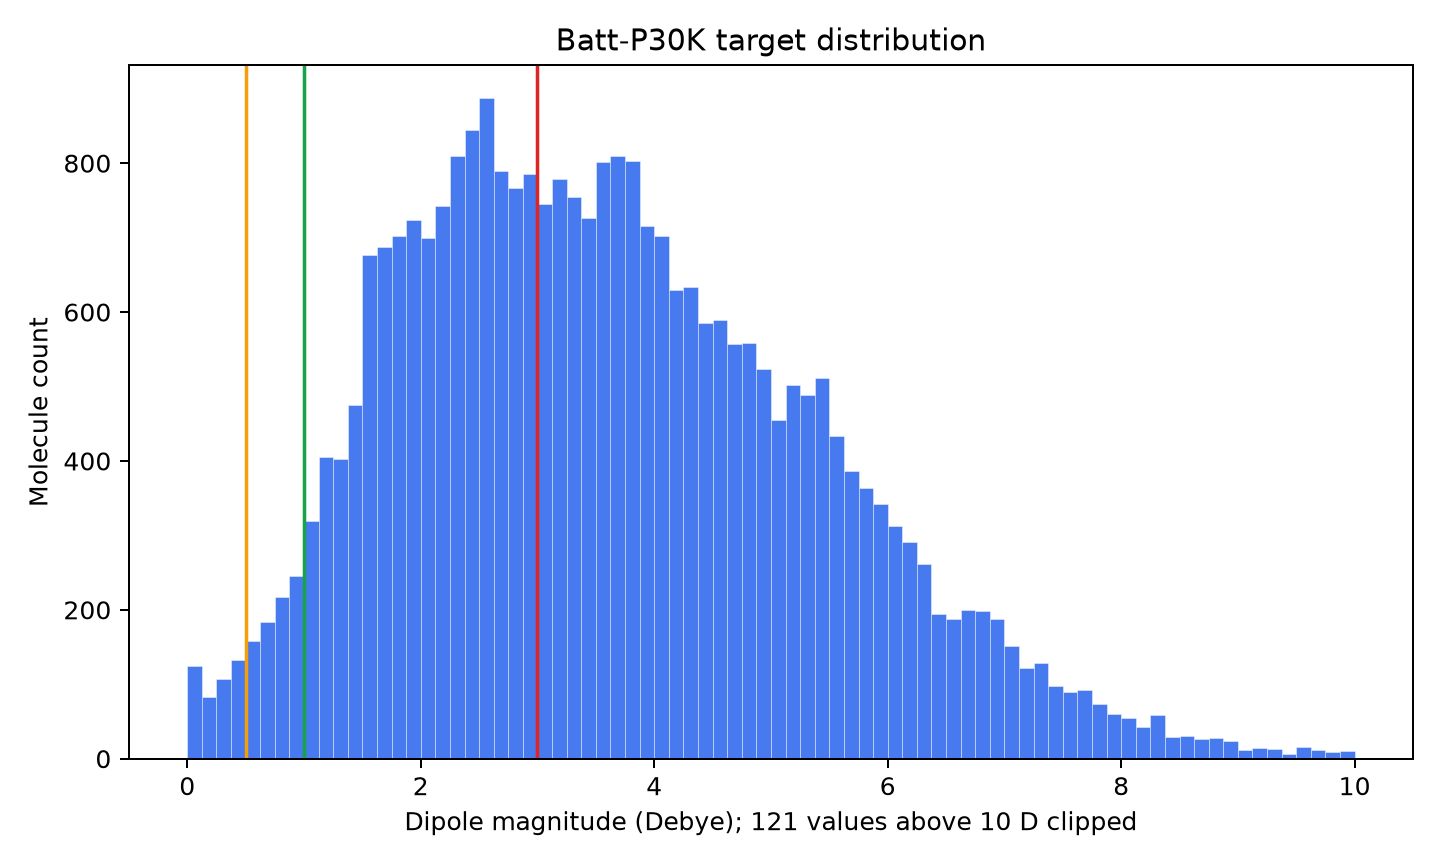

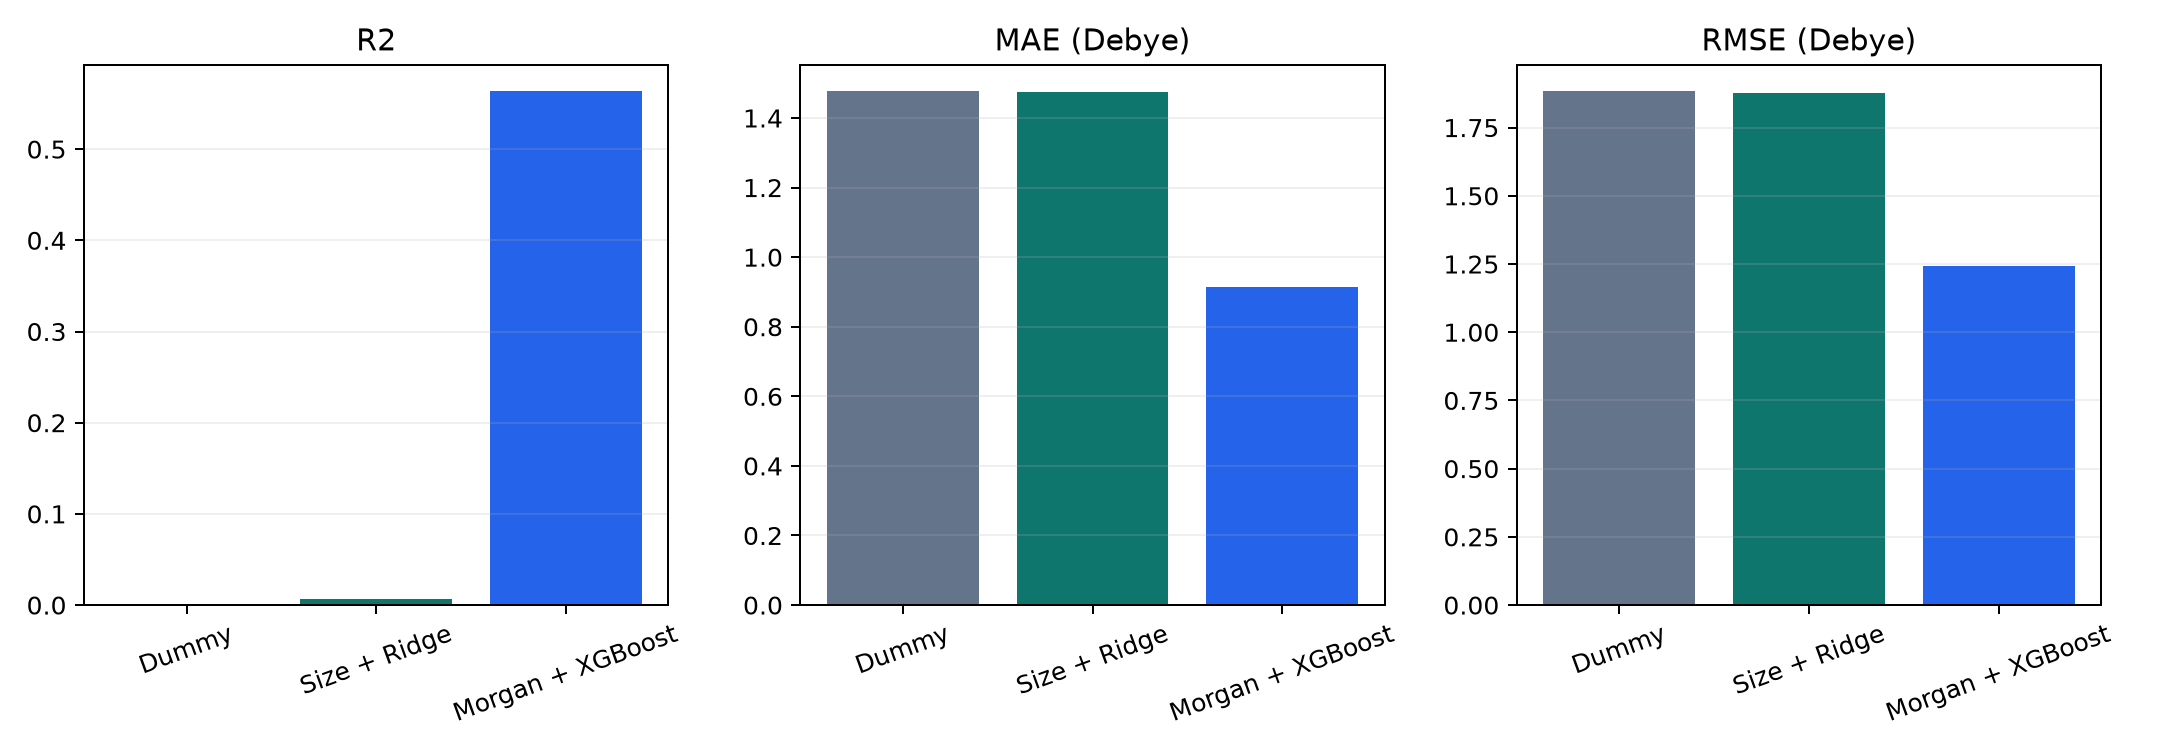

In [6]:
display(Image(filename=str(ROOT / "probes" / "artifacts" / "p2_target_distribution_debye.png")))
display(Image(filename=str(ROOT / "probes" / "artifacts" / "p2_model_comparison.png")))